1. Imports and display options

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

2. Load raw data

In [3]:
data_path = "../data/raw/transactions_fraud.csv"

df = pd.read_csv(data_path)
df.head()

,transaction_id,customer_id,device_id,merchant_id,timestamp,amount,payment_method,is_international,merchant_category,ip_address_risk_score,device_trust_score,txn_count_last_24h,avg_amount_last_24h,merchant_diversity_last_7d,device_change_flag,location_change_flag,authentication_method,otp_success_rate_customer,past_fraud_count_customer,past_disputes_customer,merchant_historical_fraud_rate,hour_of_day,day_of_week,is_weekend,is_fraud
0,1,1357,20937,720,1/18/24 19:23,18780.52,WALLET,0,Travel,0.243550,0.116606,7,6055.25,3,0,0,NONE,0.769328,1,2,0.069502,19,3,0,0
1,2,4095,29542,764,3/30/24 2:22,18955.06,CARD,0,Electronics,0.119761,0.030579,1,13366.74,5,0,1,OTP,0.468411,1,1,0.010010,2,5,1,0
2,3,3618,25236,671,1/4/24 17:26,10743.34,UPI,0,Fashion,0.565367,0.183770,0,7359.14,4,0,0,PIN,0.464356,0,1,0.118434,17,3,0,0
3,4,2755,29904,624,1/27/24 16:00,5054.75,CARD,0,Utilities,0.843842,0.717286,5,10923.57,6,0,0,PIN,0.635799,0,3,0.114947,16,5,1,0
4,5,2732,24151,501,2/20/24 23:14,14799.50,CARD,0,Gaming,0.202402,0.041616,11,6027.72,10,1,0,OTP,0.684301,2,0,0.014550,23,1,0,0


3. Basic structure and types

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   transaction_id                  50000 non-null  int64  
 1   customer_id                     50000 non-null  int64  
 2   device_id                       50000 non-null  int64  
 3   merchant_id                     50000 non-null  int64  
 4   timestamp                       50000 non-null  object 
 5   amount                          50000 non-null  float64
 6   payment_method                  50000 non-null  object 
 7   is_international                50000 non-null  int64  
 8   merchant_category               50000 non-null  object 
 9   ip_address_risk_score           50000 non-null  float64
 10  device_trust_score              50000 non-null  float64
 11  txn_count_last_24h              50000 non-null  int64  
 12  avg_amount_last_24h             

4. Rename columns to snake_case

In [5]:
rename_map = {
    "txn_count_last_24h": "velocity_24h",
    "hour_of_day": "time_of_day"
}

df.rename(columns=rename_map, inplace=True)
df.head()

,transaction_id,customer_id,device_id,merchant_id,timestamp,amount,payment_method,is_international,merchant_category,ip_address_risk_score,device_trust_score,velocity_24h,avg_amount_last_24h,merchant_diversity_last_7d,device_change_flag,location_change_flag,authentication_method,otp_success_rate_customer,past_fraud_count_customer,past_disputes_customer,merchant_historical_fraud_rate,time_of_day,day_of_week,is_weekend,is_fraud
0,1,1357,20937,720,1/18/24 19:23,18780.52,WALLET,0,Travel,0.243550,0.116606,7,6055.25,3,0,0,NONE,0.769328,1,2,0.069502,19,3,0,0
1,2,4095,29542,764,3/30/24 2:22,18955.06,CARD,0,Electronics,0.119761,0.030579,1,13366.74,5,0,1,OTP,0.468411,1,1,0.010010,2,5,1,0
2,3,3618,25236,671,1/4/24 17:26,10743.34,UPI,0,Fashion,0.565367,0.183770,0,7359.14,4,0,0,PIN,0.464356,0,1,0.118434,17,3,0,0
3,4,2755,29904,624,1/27/24 16:00,5054.75,CARD,0,Utilities,0.843842,0.717286,5,10923.57,6,0,0,PIN,0.635799,0,3,0.114947,16,5,1,0
4,5,2732,24151,501,2/20/24 23:14,14799.50,CARD,0,Gaming,0.202402,0.041616,11,6027.72,10,1,0,OTP,0.684301,2,0,0.014550,23,1,0,0


5. Basic stats and label distribution

In [6]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
transaction_id,50000.0,NaN,NaN,NaN,25000.5,14433.901067,1.0,12500.75,25000.5,37500.25,50000.0
customer_id,50000.0,NaN,NaN,NaN,2997.25424,1155.746991,1000.0,1994.0,3002.0,3996.0,4999.0
device_id,50000.0,NaN,NaN,NaN,25002.29148,2883.264316,20000.0,22513.0,25010.5,27496.0,29999.0
merchant_id,50000.0,NaN,NaN,NaN,650.02924,86.47709,500.0,575.0,650.0,725.0,799.0
timestamp,50000,41413,1/28/24 6:57,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
amount,50000.0,NaN,NaN,NaN,10015.213203,5756.852793,50.51,5007.7125,9971.515,15017.2825,19999.08
payment_method,50000,4,UPI,27573,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_international,50000.0,NaN,NaN,NaN,0.02958,0.169427,0.0,0.0,0.0,0.0,1.0
merchant_category,50000,6,Electronics,8399,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ip_address_risk_score,50000.0,NaN,NaN,NaN,0.499724,0.287707,0.000026,0.250929,0.498304,0.749212,0.999984


Fraud counts:
 is_fraud
0    44972
1     5028
Name: count, dtype: int64

Fraud ratio: 10.0560%


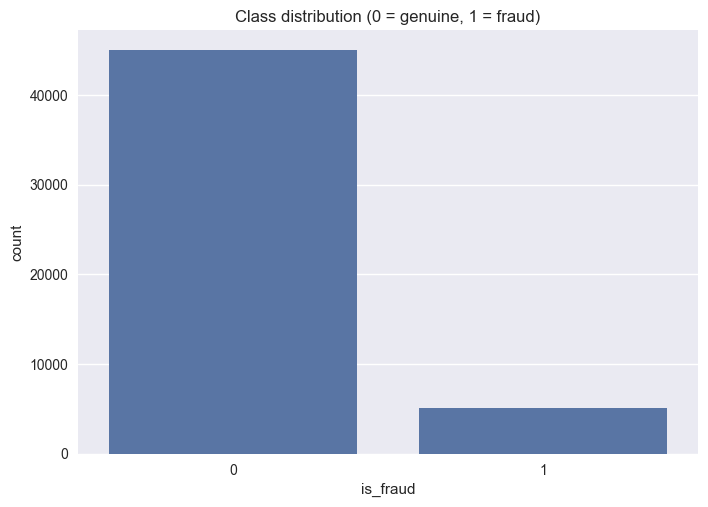

In [7]:
# Fraud vs non-fraud counts
fraud_counts = df["is_fraud"].value_counts()
fraud_ratio = df["is_fraud"].mean()
print("Fraud counts:\n", fraud_counts)
print(f"\nFraud ratio: {fraud_ratio:.4%}")

sns.countplot(x="is_fraud", data=df)
plt.title("Class distribution (0 = genuine, 1 = fraud)")
plt.show()

6. Missing values overview

In [8]:
missing = df.isnull().mean().sort_values(ascending=False)
missing[missing > 0]

Series([], dtype: float64)

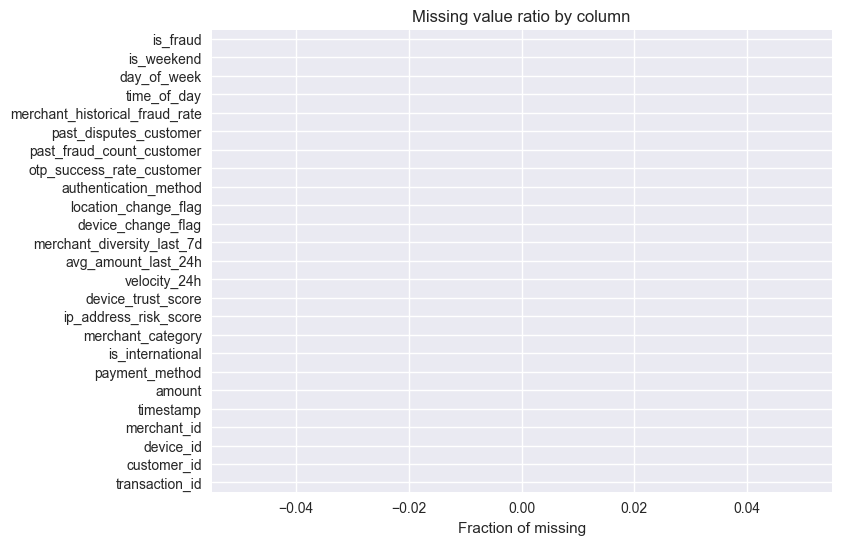

In [11]:
plt.figure(figsize=(8, 6))
missing.plot(kind="barh")
plt.title("Missing value ratio by column")
plt.xlabel("Fraction of missing")
plt.show()

7. Amount distribution

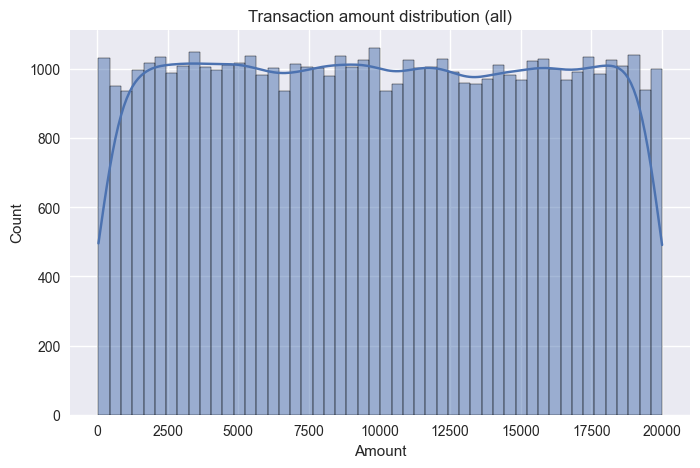

In [12]:
plt.figure(figsize=(8, 5))
sns.histplot(data= df, x="amount", bins=50, kde=True)
plt.title("Transaction amount distribution (all)")
plt.xlabel("Amount")
plt.show()

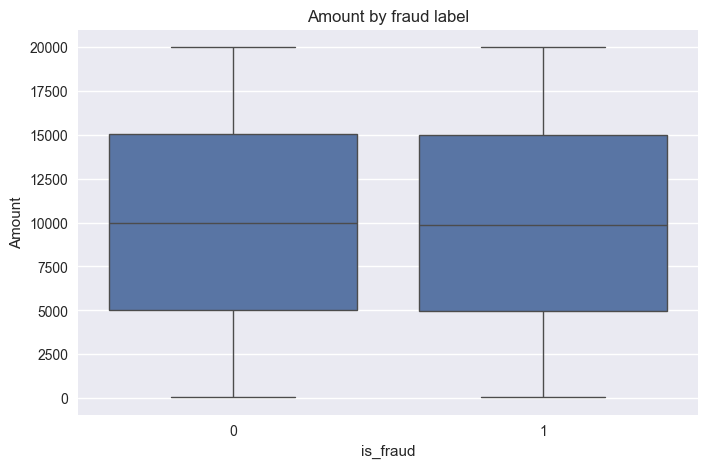

In [13]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="is_fraud", y="amount", data=df)
plt.title("Amount by fraud label")
plt.xlabel("is_fraud")
plt.ylabel("Amount")
plt.show()

8. Key risk scores vs fraud

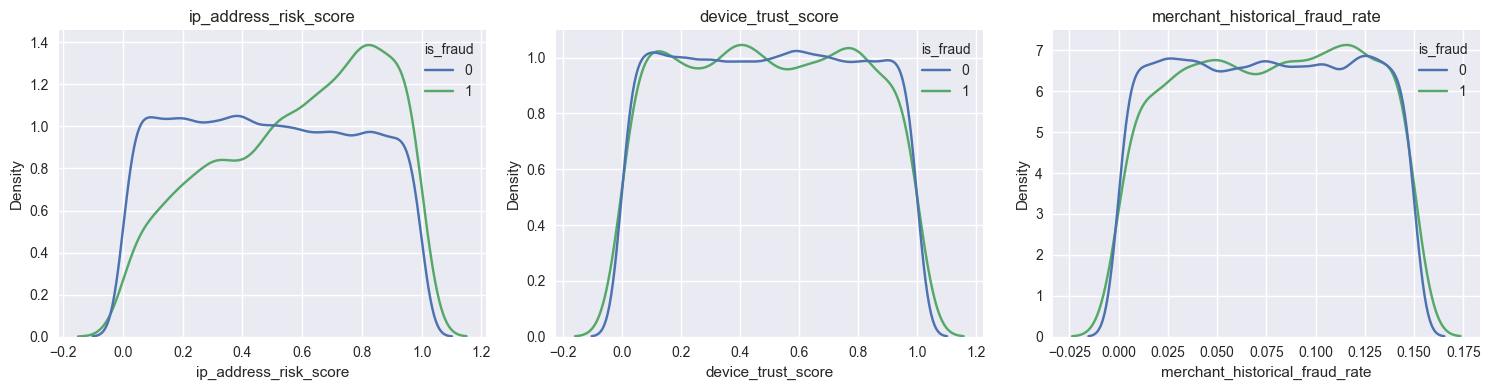

In [14]:
risk_cols = [
    "ip_address_risk_score",
    "device_trust_score",
    "merchant_historical_fraud_rate",
]

fig, axes = plt.subplots(1, len(risk_cols), figsize=(5 * len(risk_cols), 4))
for ax, col in zip(axes, risk_cols):
    sns.kdeplot(
        data=df,
        x=col,
        hue="is_fraud",
        common_norm=False,
        ax=ax,
    )
    ax.set_title(col)
plt.tight_layout()
plt.show()

9. Categorical fraud rates

In [15]:
def fraud_rate_by(col):
    tmp = (
        df.groupby(col)["is_fraud"]
        .agg(["mean", "count"])
        .rename(columns={"mean": "fraud_rate", "count": "count"})
        .sort_values("fraud_rate", ascending=False)
    )
    return tmp

fraud_rate_by("payment_method")

,fraud_rate,count
payment_method,,
NETBANKING,0.103899,5053
UPI,0.101440,27573
CARD,0.098682,12444
WALLET,0.096957,4930


In [16]:
fraud_rate_by("merchant_category")

,fraud_rate,count
merchant_category,,
Utilities,0.103452,8226
Gaming,0.102537,8397
Electronics,0.101083,8399
Grocery,0.100432,8334
Fashion,0.098146,8253
Travel,0.097724,8391


In [17]:
fraud_rate_by("is_international")

,fraud_rate,count
is_international,,
1,0.130494,1479
0,0.099648,48521


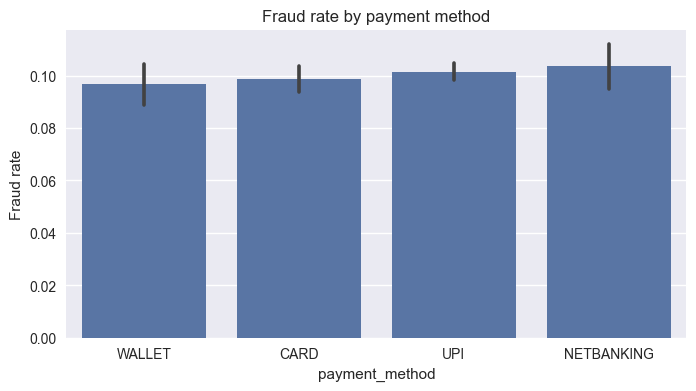

In [18]:
plt.figure(figsize=(8, 4))
sns.barplot(
    x="payment_method",
    y="is_fraud",
    data=df,
    estimator=np.mean,
)
plt.title("Fraud rate by payment method")
plt.ylabel("Fraud rate")
plt.show()

10. Temporal patterns

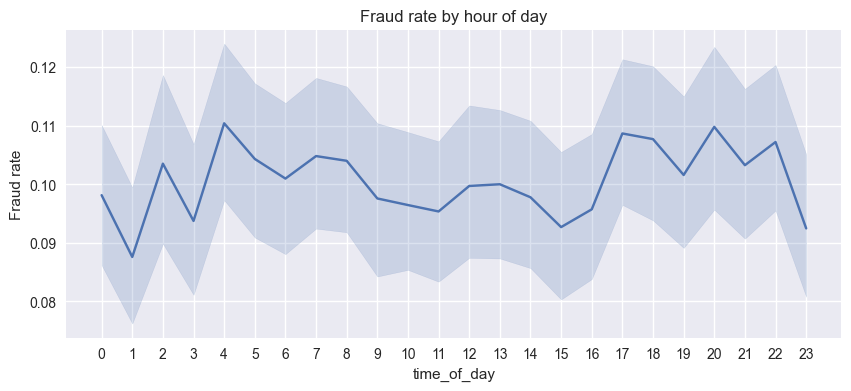

In [20]:
plt.figure(figsize=(10, 4))
sns.lineplot(
    x="time_of_day",
    y="is_fraud",
    data=df,
    estimator=np.mean,
)
plt.title("Fraud rate by hour of day")
plt.ylabel("Fraud rate")
plt.xticks(range(0, 24))
plt.show()

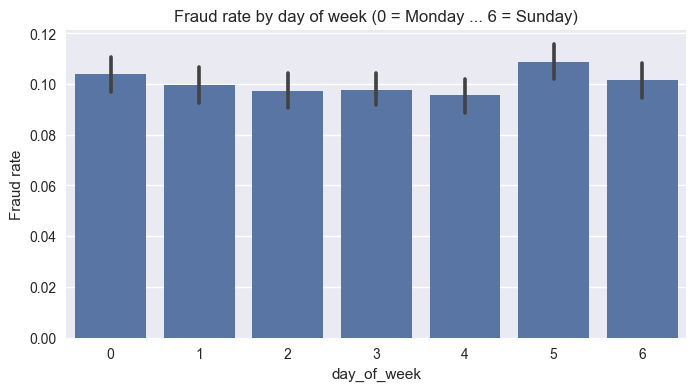

In [21]:
plt.figure(figsize=(8, 4))
sns.barplot(
    x="day_of_week",
    y="is_fraud",
    data=df,
    estimator=np.mean,
)
plt.title("Fraud rate by day of week (0 = Monday ... 6 = Sunday)")
plt.ylabel("Fraud rate")
plt.show()

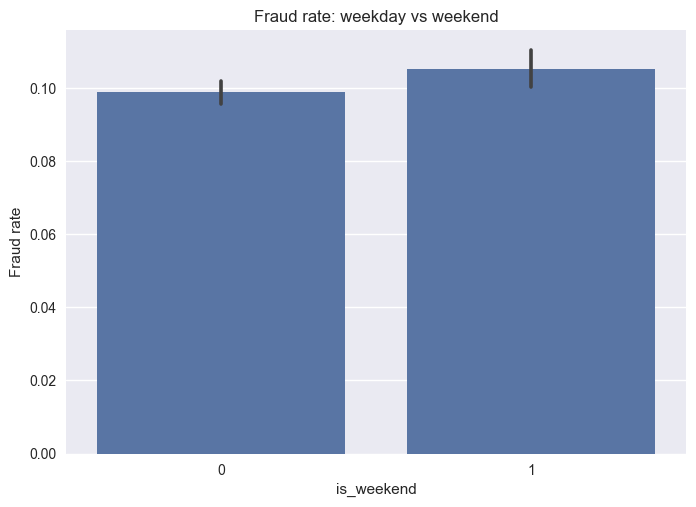

In [22]:
sns.barplot(
    x="is_weekend",
    y="is_fraud",
    data=df,
    estimator=np.mean,
)
plt.title("Fraud rate: weekday vs weekend")
plt.ylabel("Fraud rate")
plt.show()

11. Velocity / behavioural features

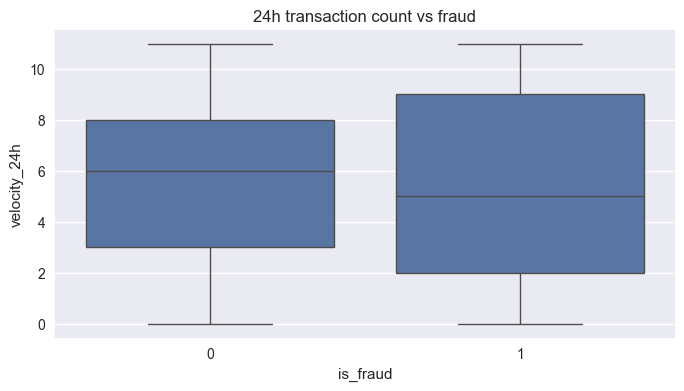

In [24]:
plt.figure(figsize=(8, 4))
sns.boxplot(x="is_fraud", y="velocity_24h", data=df)
plt.title("24h transaction count vs fraud")
plt.show()

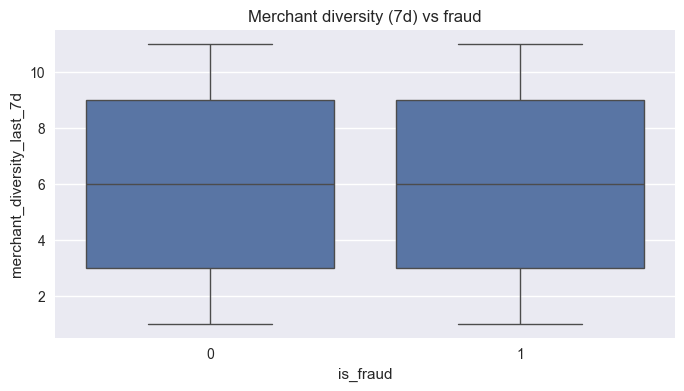

In [25]:
plt.figure(figsize=(8, 4))
sns.boxplot(x="is_fraud", y="merchant_diversity_last_7d", data=df)
plt.title("Merchant diversity (7d) vs fraud")
plt.show()

12. Correlation heatmap

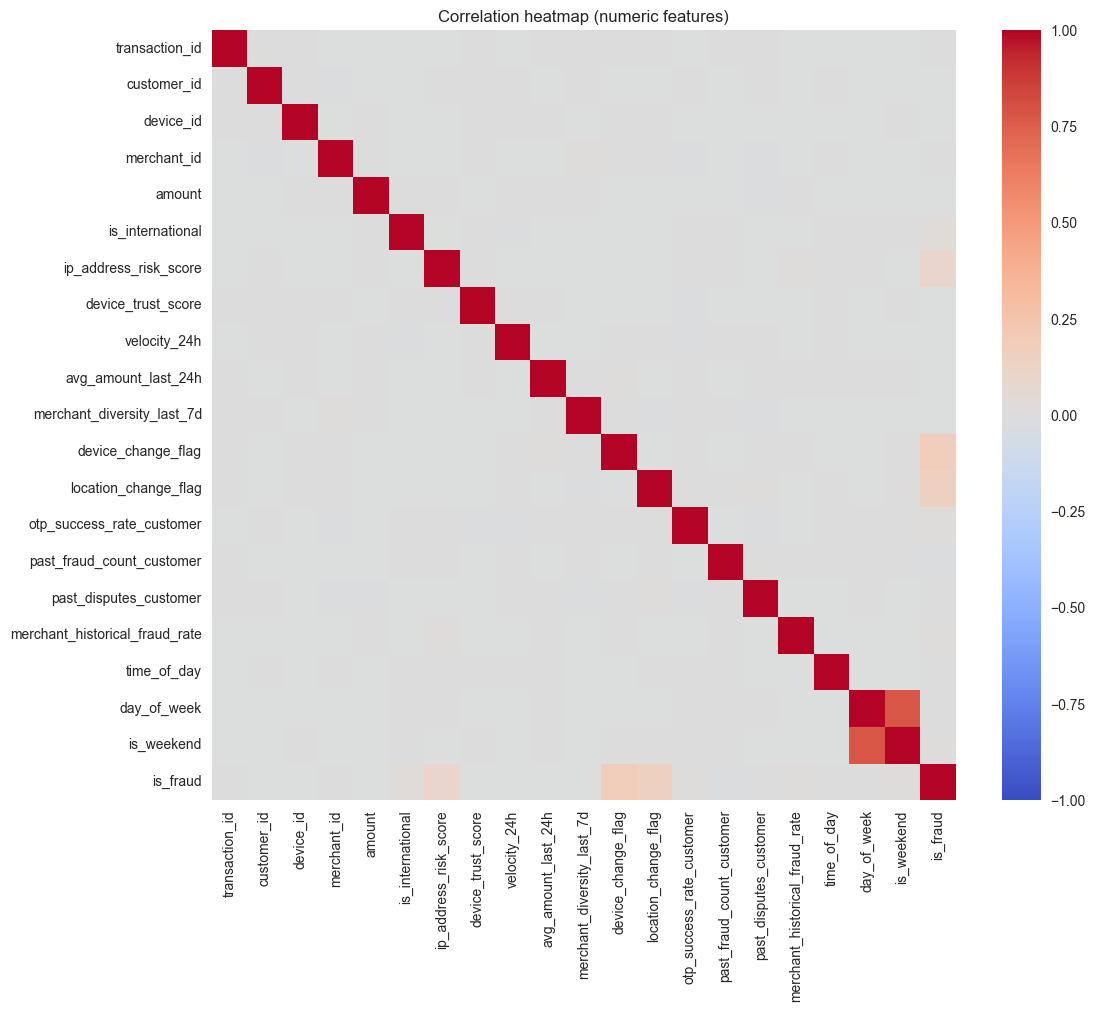

In [26]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr = df[numeric_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0.0,
    vmax=1.0,
    vmin=-1.0,
    square=False,
)
plt.title("Correlation heatmap (numeric features)")
plt.show()

In [27]:
# Save cleaned data for modeling
df.to_csv("../data/interim/transactions_clean.csv", index=False)
print("Cleaned data saved to ../data/interim/transactions_clean.csv")

Cleaned data saved to ../data/interim/transactions_clean.csv
